# Lab 7b Exercises: Vision Transformers

**Filled notebook:**
[![View on Github](https://img.shields.io/static/v1.svg?logo=github&label=Repo&message=View%20On%20Github&color=lightgrey)](https://github.com/JasminaZHAW/MLDM2/blob/main/labs/Lab_7b_Vision_Transformer_Exercise.ipynb)
  
**Pre-trained models:**
[![View files on Github](https://img.shields.io/static/v1.svg?logo=github&label=Repo&message=View%20On%20Github&color=lightgrey)](https://github.com/phlippe/saved_models/tree/main/tutorial15)
[![GoogleDrive](https://img.shields.io/static/v1.svg?logo=google-drive&logoColor=yellow&label=GDrive&message=Download&color=yellow)](https://drive.google.com/drive/folders/1BmisSPs5BXQKpolyHp5X4klSAhpDx479?usp=sharing)   


In this tutorial, we will take a closer look at a recent new trend: Transformers for Computer Vision. Since [Alexey Dosovitskiy et al.](https://openreview.net/pdf?id=YicbFdNTTy) successfully applied a Transformer on a variety of image recognition benchmarks, there have been an incredible amount of follow-up works showing that CNNs might not be optimal architecture for Computer Vision anymore. But how do Vision Transformers work exactly, and what benefits and drawbacks do they offer in contrast to CNNs? We will answer these questions by implementing a Vision Transformer ourselves and train it on the popular, small dataset CIFAR10. We will compare these results to the convolutional architectures of Lab 5.

We will use [PyTorch Lightning](https://www.pytorchlightning.ai/) again (introduced in Lab 5). Let's start with importing our standard set of libraries.

In [1]:
# PyTorch Lightning
try:
    import pytorch_lightning as pl
except ModuleNotFoundError: # Google Colab does not have PyTorch Lightning installed by default. Hence, we do it here if necessary
    !pip install --quiet pytorch-lightning>=1.5
    import pytorch_lightning as pl

In [13]:
## Standard libraries
import os
import numpy as np
import random
import math
import json
from functools import partial
from PIL import Image

## Imports for plotting
import matplotlib.pyplot as plt
plt.set_cmap('cividis')
%matplotlib inline
from matplotlib.colors import to_rgb
import matplotlib
matplotlib.rcParams['lines.linewidth'] = 2.0
import seaborn as sns
sns.reset_orig()

## tqdm for loading bars
from tqdm.notebook import tqdm

## PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torch.optim as optim

## Torchvision
import torchvision
from torchvision.datasets import CIFAR10
from torchvision import transforms

# PyTorch Lightning
try:
    import pytorch_lightning as pl
except ModuleNotFoundError: # Google Colab does not have PyTorch Lightning installed by default. Hence, we do it here if necessary
    !pip install --quiet pytorch-lightning>=1.4
    import pytorch_lightning as pl
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint

# Import tensorboard
%load_ext tensorboard

# Path to the folder where the datasets are/should be downloaded (e.g. CIFAR10)
DATASET_PATH = "/Users/schiba/data"
# Path to the folder where the pretrained models are saved
CHECKPOINT_PATH = "semester-6/dl/saved_models/lab7b"

# Setting the seed
pl.seed_everything(42)

# Ensure that all operations are deterministic on GPU (if used) for reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("mps")
print(f"Using device: {device}")

Seed set to 42


The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard
Using device: mps


<Figure size 640x480 with 0 Axes>

We provide a pre-trained Vision Transformer which we download in the next cell. However, Vision Transformers can be relatively quickly trained on CIFAR10 with an overall training time of less than an hour on an NVIDIA TitanRTX.

In [11]:
import urllib.request
from urllib.error import HTTPError
# Github URL where saved models are stored for this tutorial
base_url = "https://raw.githubusercontent.com/phlippe/saved_models/main/"
# Files to download
pretrained_files = ["tutorial15/ViT.ckpt", "tutorial15/tensorboards/ViT/events.out.tfevents.ViT",
                    "tutorial5/tensorboards/ResNet/events.out.tfevents.resnet"]
# Create checkpoint path if it doesn't exist yet
os.makedirs(CHECKPOINT_PATH, exist_ok=True)

# For each file, check whether it already exists. If not, try downloading it.
for file_name in pretrained_files:
    file_path = os.path.join(CHECKPOINT_PATH, file_name.split("/",1)[1])
    if "/" in file_name.split("/",1)[1]:
        os.makedirs(file_path.rsplit("/",1)[0], exist_ok=True)
    if not os.path.isfile(file_path):
        file_url = base_url + file_name
        print(f"Downloading {file_url}...")
        try:
            urllib.request.urlretrieve(file_url, file_path)
        except HTTPError as e:
            print("Something went wrong. Please try to download the file from the GDrive folder, or contact the author with the full output including the following error:\n", e)

We load the CIFAR10 dataset below. We use the same setup of the datasets and data augmentations as for the CNNs in Lab 5 to keep a fair comparison. The constants in the `transforms.Normalize` correspond to the values that scale and shift the data to a zero mean and standard deviation of one.

100%|██████████| 170M/170M [00:06<00:00, 25.7MB/s] 
Seed set to 42
Seed set to 42


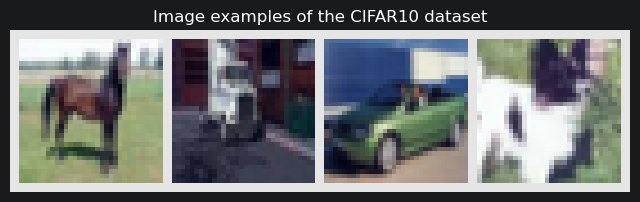

In [14]:
test_transform = transforms.Compose([transforms.ToTensor(),
                                     transforms.Normalize([0.49139968, 0.48215841, 0.44653091], [0.24703223, 0.24348513, 0.26158784])
                                     ])
# For training, we add some augmentation. Networks are too powerful and would overfit.
train_transform = transforms.Compose([transforms.RandomHorizontalFlip(),
                                      transforms.RandomResizedCrop((32,32),scale=(0.8,1.0),ratio=(0.9,1.1)),
                                      transforms.ToTensor(),
                                      transforms.Normalize([0.49139968, 0.48215841, 0.44653091], [0.24703223, 0.24348513, 0.26158784])
                                     ])
# Loading the training dataset. We need to split it into a training and validation part
# We need to do a little trick because the validation set should not use the augmentation.
train_dataset = CIFAR10(root=DATASET_PATH, train=True, transform=train_transform, download=True)
val_dataset = CIFAR10(root=DATASET_PATH, train=True, transform=test_transform, download=True)
pl.seed_everything(42)
train_set, _ = torch.utils.data.random_split(train_dataset, [45000, 5000])
pl.seed_everything(42)
_, val_set = torch.utils.data.random_split(val_dataset, [45000, 5000])

# Loading the test set
test_set = CIFAR10(root=DATASET_PATH, train=False, transform=test_transform, download=True)

# We define a set of data loaders that we can use for various purposes later.
train_loader = data.DataLoader(train_set, batch_size=128, shuffle=True, drop_last=True, pin_memory=True, num_workers=4)
val_loader = data.DataLoader(val_set, batch_size=128, shuffle=False, drop_last=False, num_workers=4)
test_loader = data.DataLoader(test_set, batch_size=128, shuffle=False, drop_last=False, num_workers=4)

# Visualize some examples
NUM_IMAGES = 4
CIFAR_images = torch.stack([val_set[idx][0] for idx in range(NUM_IMAGES)], dim=0)
img_grid = torchvision.utils.make_grid(CIFAR_images, nrow=4, normalize=True, pad_value=0.9)
img_grid = img_grid.permute(1, 2, 0)

plt.figure(figsize=(8,8))
plt.title("Image examples of the CIFAR10 dataset")
plt.imshow(img_grid)
plt.axis('off')
plt.show()
plt.close()

## Transformers for image classification

Transformers have been originally proposed to process sets since it is a permutation-equivariant architecture, i.e., producing the same output permuted if the input is permuted. To apply Transformers to sequences, we have simply added a positional encoding to the input feature vectors, and the model learned by itself what to do with it. So, why not do the same thing on images? This is exactly what [Alexey Dosovitskiy et al.](https://openreview.net/pdf?id=YicbFdNTTy) proposed in their paper "An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale". Specifically, the Vision Transformer is a model for image classification that views images as sequences of smaller patches. As a preprocessing step, we split an image of, for example, $48\times 48$ pixels into 9 $16\times 16$ patches. Each of those patches is considered to be a "word"/"token" and projected to a feature space. With adding positional encodings and a token for classification on top, we can apply a Transformer as usual to this sequence and start training it for our task. A nice GIF visualization of the architecture is shown below (figure credit - [Phil Wang](https://github.com/lucidrains/vit-pytorch/blob/main/images/vit.gif)):

<center width="100%"><img src="https://github.com/phlippe/uvadlc_notebooks/blob/master/docs/tutorial_notebooks/tutorial15/vit.gif?raw=1" width="600px"></center>

We will walk step by step through the Vision Transformer, and implement all parts by ourselves. First, let's implement the image preprocessing: an image of size $N\times N$ has to be split into $(N/M)^2$ patches of size $M\times M$. These represent the input words to the Transformer.

In [15]:
def img_to_patch(x, patch_size, flatten_channels=True):
    """
    Inputs:
        x - torch.Tensor representing the image of shape [B, C, H, W]
        patch_size - Number of pixels per dimension of the patches (integer)
        flatten_channels - If True, the patches will be returned in a flattened format
                           as a feature vector instead of a image grid.
    """
    B, C, H, W = x.shape
    x = x.reshape(B, C, H//patch_size, patch_size, W//patch_size, patch_size)
    x = x.permute(0, 2, 4, 1, 3, 5) # [B, H', W', C, p_H, p_W]
    x = x.flatten(1,2)              # [B, H'*W', C, p_H, p_W]
    if flatten_channels:
        x = x.flatten(2,4)          # [B, H'*W', C*p_H*p_W]
    return x

Let's take a look at how that works for our CIFAR examples above. For our images of size $32\times 32$, we choose a patch size of 4. Hence, we obtain sequences of 64 patches of size $4\times 4$. We visualize them below:

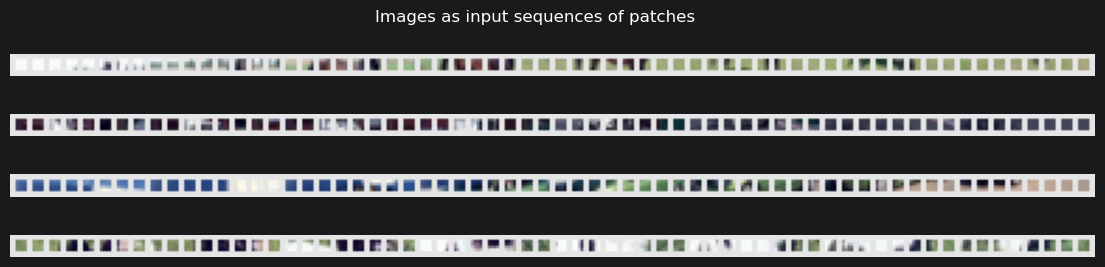

In [16]:
img_patches = img_to_patch(CIFAR_images, patch_size=4, flatten_channels=False)

fig, ax = plt.subplots(CIFAR_images.shape[0], 1, figsize=(14,3))
fig.suptitle("Images as input sequences of patches")
for i in range(CIFAR_images.shape[0]):
    img_grid = torchvision.utils.make_grid(img_patches[i], nrow=64, normalize=True, pad_value=0.9)
    img_grid = img_grid.permute(1, 2, 0)
    ax[i].imshow(img_grid)
    ax[i].axis('off')
plt.show()
plt.close()

Compared to the original images, it is much harder to recognize the objects from those patch lists now. Still, this is the input we provide to the Transformer for classifying the images. The model has to learn itself how it has to combine the patches to recognize the objects. The inductive bias in CNNs that an image is a grid of pixels, is lost in this input format.

After we have looked at the preprocessing, we can now start building the Transformer model. Since we have discussed the fundamentals of Multi-Head Attention in Lab7a, we can now use the PyTorch module `nn.MultiheadAttention` ([docs](https://pytorch.org/docs/stable/generated/torch.nn.MultiheadAttention.html?highlight=multihead#torch.nn.MultiheadAttention)) here. Further, we use the Pre-Layer Normalization version of the Transformer blocks proposed by [Ruibin Xiong et al.](http://proceedings.mlr.press/v119/xiong20b/xiong20b.pdf) in 2020. The idea is to apply Layer Normalization not in between residual blocks, but instead as a first layer in the residual blocks. This reorganization of the layers supports better gradient flow and removes the necessity of a warm-up stage. A visualization of the difference between the standard Post-LN and the Pre-LN version is shown below.

<center width="100%"><img src="https://github.com/phlippe/uvadlc_notebooks/blob/master/docs/tutorial_notebooks/tutorial15/pre_layer_norm.svg?raw=1" width="400px"></center>

[**Exersice**] Implement the Pre-LN attention block and use the `GELU` activation function in the FFN block.

In [22]:
class AttentionBlock(nn.Module):
    def __init__(self, embed_dim, hidden_dim, num_heads, dropout=0.0):
        super().__init__()

        self.layer_norm_attention = nn.LayerNorm(embed_dim)
        # Added batch_first=True
        self.multi_head = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)
        self.layer_norm_mlp = nn.LayerNorm(embed_dim)

        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, embed_dim), # Crucial: Project back to embed_dim
            nn.Dropout(dropout),
        )

    def forward(self, x):
        # Attention block with residual
        norm_x = self.layer_norm_attention(x)
        # multi_head requires (query, key, value) and returns (output, weights)
        attn_out, _ = self.multi_head(norm_x, norm_x, norm_x)
        x = x + attn_out

        # MLP block with residual
        norm_x = self.layer_norm_mlp(x)
        mlp_out = self.mlp(norm_x)
        x = x + mlp_out

        return x

Now we have all modules ready to build our own Vision Transformer. Besides the Transformer encoder, we need the following modules:

* A **linear projection** layer that maps the input patches to a feature vector of larger size. It can be implemented by a simple linear layer that takes each $M\times M$ patch independently as input.
* A **classification token** that is added to the input sequence. We will use the output feature vector of the classification token (CLS token in short) for determining the classification prediction.
* Learnable **positional encodings** that are added to the tokens before being processed by the Transformer. Those are needed to learn position-dependent information, and convert the set to a sequence. Since we usually work with a fixed resolution, we can learn the positional encodings instead of having the pattern of sine and cosine functions.
* An **MLP head** that takes the output feature vector of the CLS token, and maps it to a classification prediction. This is usually implemented by a small feed-forward network or even a single linear layer.

[**Exercise**] With those components in mind, implement the full Vision Transformer below.

In [21]:
class VisionTransformer(nn.Module):
    def __init__(self, embed_dim, hidden_dim, num_channels, num_heads, num_layers, num_classes, patch_size, num_patches, dropout=0.0):
        super().__init__()
        self.patch_size = patch_size

        # The input dimension of a flattened patch
        patch_dim = num_channels * (patch_size ** 2)
        self.input_layer = nn.Linear(patch_dim, embed_dim)

        # Fixed infinite recursion: Use AttentionBlocks
        self.transformer = nn.Sequential(*[
            AttentionBlock(embed_dim, hidden_dim, num_heads, dropout)
            for _ in range(num_layers)
        ])

        # Maps embed_dim (from CLS token) to num_classes
        self.mlp_head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, num_classes)
        )
        self.dropout = nn.Dropout(dropout)

        # Parameters/Embeddings init
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        self.pos_embedding = nn.Parameter(torch.randn(1, 1 + num_patches, embed_dim))

    def forward(self, x):
        # Preprocess input
        x = img_to_patch(x, self.patch_size)
        B, T, _ = x.shape
        x = self.input_layer(x)

        # Expand CLS token to match batch size and concatenate
        cls_token = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls_token, x], dim=1)

        # Add positional encoding
        x = x + self.pos_embedding
        x = self.dropout(x)

        # Apply Transformer
        x = self.transformer(x)

        # Perform classification prediction on the CLS token only
        cls_out = x[:, 0]
        out = self.mlp_head(cls_out)

        return out

[**Exercise**] Put everything into a PyTorch Lightning Module. Use `torch.optim.AdamW` as the optimizer, which is Adam with a corrected weight decay implementation. Note that since we use the Pre-LN Transformer version, we do not need to use a learning rate warmup stage anymore. Instead, we use the same learning rate scheduler as the CNNs in our previous lab on image classification.

In [20]:
class ViT(pl.LightningModule):
    def __init__(self, lr, **model_kwargs):
        super().__init__()
        self.save_hyperparameters()
        self.model = VisionTransformer(**model_kwargs)
        # Assuming images are 3x32x32 for example input
        self.example_input_array = torch.randn(1, 3, 32, 32)
        self.lr = lr

    def forward(self, x):
        return self.model(x)

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(lr=self.lr, params=self.model.parameters())
        lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5)

        # Fixed: Dict format is required for ReduceLROnPlateau
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": lr_scheduler,
                "monitor": "val_loss",
            },
        }

    def _calculate_loss(self, batch, mode="train"):
        y_hat = self.forward(batch[0])
        loss = F.cross_entropy(y_hat, batch[1])
        acc = y_hat.argmax(dim=1).eq(batch[1]).float().mean()
        self.log(f'{mode}_loss', loss, prog_bar=True)
        self.log(f'{mode}_acc', acc, prog_bar=True)
        return loss

    def training_step(self, batch, batch_idx):
        loss = self._calculate_loss(batch, mode="train")
        return loss

    def validation_step(self, batch, batch_idx):
        self._calculate_loss(batch, mode="val")

    def test_step(self, batch, batch_idx):
        self._calculate_loss(batch, mode="test")

## Experiments

Commonly, Vision Transformers are applied to large-scale image classification benchmarks such as ImageNet to leverage their full potential. However, here we take a step back and ask: can Vision Transformer also succeed on classical, small benchmarks such as CIFAR10? To find this out, we train a Vision Transformer from scratch on the CIFAR10 dataset.

[**Exercise**] Implement a training function for the PyTorch Lightning module `ViT`.

In [28]:
def train_model(**kwargs):
    # 1. Set seed for reproducibility
    pl.seed_everything(42)

    # 2. Initialize the model
    model = ViT(lr=kwargs['lr'], **kwargs['model_kwargs'])

    # 3. Create a callback to save the best model weights
    checkpoint_callback = ModelCheckpoint(
        monitor="val_loss", # Look at validation loss to decide if the model improved
        mode="min",         # We want the loss to be minimized
        save_top_k=1        # Only save the single best model
    )

    # 4. Initialize the Trainer
    trainer = pl.Trainer(
        default_root_dir="vit_logs", # Where to save the logs and checkpoints
        max_epochs=15,               # Number of times to loop through the training data
        callbacks=[checkpoint_callback]
    )

    # Optional logger tweaks (from your original snippet)
    if trainer.logger:
        trainer.logger._log_graph = True
        trainer.logger._default_hp_metric = None

    # 5. Train the model
    trainer.fit(model, train_loader, val_loader)

    # 6. Test best model on validation and test set
    val_result = trainer.test(model, dataloaders=val_loader, ckpt_path="best")
    test_result = trainer.test(model, dataloaders=test_loader, ckpt_path="best")

    # 7. Format the results
    result = {"test": test_result[0]["test_acc"], "val": val_result[0]["test_acc"]}

    return model, result

Now, we can already start training our model. As seen in our implementation, we have a couple of hyperparameters that we have to set. When creating this notebook, we have performed a small grid search over hyperparameters and listed the best hyperparameters in the cell below. Nevertheless, it is worth discussing the influence that each hyperparameter has, and what intuition we have for choosing its value.

First, let's consider the patch size. The smaller we make the patches, the longer the input sequences to the Transformer become. While in general, this allows the Transformer to model more complex functions, it requires a longer computation time due to its quadratic memory usage in the attention layer. Furthermore, small patches can make the task more difficult since the Transformer has to learn which patches are close-by, and which are far away. We experimented with patch sizes of 2, 4, and 8 which gives us the input sequence lengths of 256, 64, and 16 respectively. We found 4 to result in the best performance and hence pick it below.

Next, the embedding and hidden dimensionality have a similar impact on a Transformer as to an MLP. The larger the sizes, the more complex the model becomes, and the longer it takes to train. In Transformers, however, we have one more aspect to consider: the query-key sizes in the Multi-Head Attention layers. Each key has the feature dimensionality of `embed_dim/num_heads`. Considering that we have an input sequence length of 64, a minimum reasonable size for the key vectors is 16 or 32. Lower dimensionalities can restrain the possible attention maps too much. We observed that more than 8 heads are not necessary for the Transformer, and therefore pick an embedding dimensionality of `256`. The hidden dimensionality in the feed-forward networks is usually 2-4x larger than the embedding dimensionality, and thus we pick `512`.

Finally, the learning rate for Transformers is usually relatively small, and in papers, a common value to use is 3e-5. However, since we work with a smaller dataset and have a potentially easier task, we found that we are able to increase the learning rate to 3e-4 without any problems. To reduce overfitting, we use a dropout value of 0.2. Remember that we also use small image augmentations as regularization during training.

Feel free to explore the hyperparameters yourself by changing the values below. In general, the Vision Transformer did not show to be too sensitive to the hyperparameter choices on the CIFAR10 dataset.

In [29]:
model, results = train_model(model_kwargs={
                                'embed_dim': 256,
                                'hidden_dim': 512,
                                'num_heads': 8,
                                'num_layers': 6,
                                'patch_size': 4,
                                'num_channels': 3,
                                'num_patches': 64,
                                'num_classes': 10,
                                'dropout': 0.2
                            },
                            lr=3e-4)
print("ViT results", results)

Seed set to 42
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name  | Type              | Params | Mode  | FLOPs | In sizes       | Out sizes
-----------------------------------------------------------------------------------------
0 | model | VisionTransformer | 3.2 M  | train | 436 M | [1, 3, 32, 32] | [1, 10]  
-----------------------------------------------------------------------------------------
3.2 M     Trainable params
0         Non-trainable params
3.2 M     Total params
12.781    Total estimated model params size (MB)
73        Modules in train mode
0         Modules in eval mode
436 M     Total Flops


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Users/schiba/miniforge3/envs/deep-learning/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:429: Consider setting `persistent_workers=True` in 'val_dataloader' to speed up the dataloader worker initialization.


/Users/schiba/miniforge3/envs/deep-learning/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:429: Consider setting `persistent_workers=True` in 'train_dataloader' to speed up the dataloader worker initialization.
/Users/schiba/miniforge3/envs/deep-learning/lib/python3.12/site-packages/torch/utils/data/dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 0: 100%|██████████| 351/351 [00:58<00:00,  6.01it/s, v_num=0, train_loss=1.560, train_acc=0.430]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 1: 100%|██████████| 351/351 [01:25<00:00,  4.10it/s, v_num=0, train_loss=1.510, train_acc=0.484, val_loss=1.440, val_acc=0.481]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 2: 100%|██████████| 351/351 [01:27<00:00,  4.01it/s, v_num=0, train_loss=1.340, train_acc=0.484, val_loss=1.320, val_acc=0.521]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 3: 100%|██████████| 351/351 [01:26<00:00,  4.06it/s, v_num=0, train_loss=1.230, train_acc=0.594, val_loss=1.220, val_acc=0.564]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 4: 100%|██████████| 351/351 [01:23<00:00,  4.21it/s, v_num=0, train_loss=1.250, train_acc=0.523, val_loss=1.180, val_acc=

...

Epoch 14: 100%|██████████| 351/351 [01:53<00:00,  3.10it/s, v_num=0, train_loss=0.981, train_acc=0.664, val_loss=0.935, val_acc=0.670]


Restoring states from the checkpoint path at vit_logs/lightning_logs/version_0/checkpoints/epoch=13-step=4914.ckpt
Loaded model weights from the checkpoint at vit_logs/lightning_logs/version_0/checkpoints/epoch=13-step=4914.ckpt
/Users/schiba/miniforge3/envs/deep-learning/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:429: Consider setting `persistent_workers=True` in 'test_dataloader' to speed up the dataloader worker initialization.


Testing DataLoader 0: 100%|██████████| 40/40 [00:02<00:00, 19.96it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc             0.66839998960495
        test_loss           0.9258274435997009
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


Restoring states from the checkpoint path at vit_logs/lightning_logs/version_0/checkpoints/epoch=13-step=4914.ckpt
Loaded model weights from the checkpoint at vit_logs/lightning_logs/version_0/checkpoints/epoch=13-step=4914.ckpt


Testing DataLoader 0: 100%|██████████| 79/79 [00:03<00:00, 22.41it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.6707000136375427
        test_loss           0.9315931797027588
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
ViT results {'test': 0.6707000136375427, 'val': 0.66839998960495}


The Vision Transformer achieves a validation and test performance of about 75%. In comparison, almost all CNN architectures that we have tested in Lab 5 obtained a classification performance of around 90%. This is a considerable gap and shows that although Vision Transformers perform strongly on ImageNet with potential pretraining, they cannot come close to simple CNNs on CIFAR10 when being trained from scratch. The differences between a CNN and Transformer can be well observed in the training curves. Let's look at them in a tensorboard below:

In [32]:
# Opens tensorboard in notebook. Adjust the path to your CHECKPOINT_PATH!
%tensorboard --logdir /vit_logs/lightning_logs/version_0/

<center><img src="https://github.com/phlippe/uvadlc_notebooks/blob/master/docs/tutorial_notebooks/tutorial15/tensorboard_screenshot.png?raw=1" width="100%"/></center>

The tensorboard compares the Vision Transformer to a ResNet trained on CIFAR10. When looking at the training losses, we see that the ResNet learns much more quickly in the first iterations. While the learning rate might have an influence on the initial learning speed, we see the same trend in the validation accuracy. The ResNet achieves the best performance of the Vision Transformer after just 5 epochs (2000 iterations). Further, while the ResNet training loss and validation accuracy have a similar trend, the validation performance of the Vision Transformers only marginally changes after 10k iterations while the training loss has almost just started going down. Yet, the Vision Transformer is also able to achieve close to 100% accuracy on the training set.

All those observed phenomenons can be explained with a concept that we have visited before: inductive biases. Convolutional Neural Networks have been designed with the assumption that images are translation invariant. Hence, we apply convolutions with shared filters across the image. Furthermore, a CNN architecture integrates the concept of distance in an image: two pixels that are close to each other are more related than two distant pixels. Local patterns are combined into larger patterns until we perform our classification prediction. All those aspects are inductive biases of a CNN. In contrast, a Vision Transformer does not know which two pixels are close to each other, and which are far apart. It has to learn this information solely from the sparse learning signal of the classification task. This is a huge disadvantage when we have a small dataset since such information is crucial for generalizing to an unseen test dataset. With large enough datasets and/or good pre-training, a Transformer can learn this information without the need for inductive biases, and instead is more flexible than a CNN. Especially long-distance relations between local patterns can be difficult to process in CNNs, while in Transformers, all patches have the distance of one. This is why Vision Transformers are so strong on large-scale datasets such as ImageNet but underperform a lot when being applied to a small dataset such as CIFAR10.

## Conclusion

In this tutorial, we have implemented our own Vision Transformer from scratch and applied it to the task of image classification. Vision Transformers work by splitting an image into a sequence of smaller patches, use those as input to a standard Transformer encoder. While Vision Transformers achieved outstanding results on large-scale image recognition benchmarks such as ImageNet, they considerably underperform when being trained from scratch on small-scale datasets like CIFAR10. The reason is that in contrast to CNNs, Transformers do not have the inductive biases of translation invariance and the feature hierarchy (i.e. larger patterns consist of many smaller patterns). However, these aspects can be learned when enough data is provided, or the model has been pre-trained on other large-scale tasks.


### References

Dosovitskiy, Alexey, et al. "An image is worth 16x16 words: Transformers for image recognition at scale." International Conference on Learning Representations (2021). [link](https://arxiv.org/pdf/2010.11929.pdf)

Chen, Xiangning, et al. "When Vision Transformers Outperform ResNets without Pretraining or Strong Data Augmentations." arXiv preprint arXiv:2106.01548 (2021). [link](https://arxiv.org/abs/2106.01548)

Tolstikhin, Ilya, et al. "MLP-mixer: An all-MLP Architecture for Vision." arXiv preprint arXiv:2105.01601 (2021). [link](https://arxiv.org/abs/2105.01601)

Xiong, Ruibin, et al. "On layer normalization in the transformer architecture." International Conference on Machine Learning. PMLR, 2020. [link](http://proceedings.mlr.press/v119/xiong20b/xiong20b.pdf)

**Adjusted for MLDM2 from:**
[![View on Github](https://img.shields.io/static/v1.svg?logo=github&label=Repo&message=View%20On%20Github&color=lightgrey)](https://github.com/phlippe/uvadlc_notebooks/blob/master/docs/tutorial_notebooks/tutorial15/Vision_Transformer.ipynb)
[![Open In Collab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phlippe/uvadlc_notebooks/blob/master/docs/tutorial_notebooks/tutorial15/Vision_Transformer.ipynb)   
  
**Recordings:**
[![YouTube - Part 1](https://img.shields.io/static/v1.svg?logo=youtube&label=YouTube&message=Part%201&color=red)](https://youtu.be/4UyBxlJChfc)   
  
**Author:** Phillip Lippe

MIT License

Copyright (c) 2020 Phillip Lippe

Permission is hereby granted, free of charge, to any person obtaining a copy of this software and associated documentation files (the "Software"), to deal in the Software without restriction, including without limitation the rights to use, copy, modify, merge, publish, distribute, sublicense, and/or sell copies of the Software, and to permit persons to whom the Software is furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY, FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM, OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE SOFTWARE.